# Mô hình Decision Tree

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
# Tải dữ liệu
df = pd.read_csv('/home/ashine/Downloads/detection_anomaly/dataset/Encoded.csv')
print("Tổng số cột:", len(df.columns))
print("Danh sách các trường:\n", df.columns.tolist())

In [ ]:
columns_to_keep = [
    'Seq', 'Mean', 'sTos', 'sTtl', 'dTtl', 'sHops', 'TotBytes', 
    'SrcBytes', 'Offset', 'sMeanPktSz', 'dMeanPktSz', 'SrcWin', 
    'TcpRtt', 'AckDat', 'Label', ' e        ', ' e d      ', 
    'icmp', 'tcp', 'CON', 'FIN', 'INT', 'REQ', 'RST', 'Status', 'cs0'
]
df = pd.read_csv('/home/ashine/Downloads/detection_anomaly/dataset/Encoded.csv', usecols=columns_to_keep)
print("Tổng số cột sau khi chọn:", len(df.columns))
print("Danh sách các trường sau khi chọn:\n", df.columns.tolist())
df.head(5)


Tổng số cột sau khi chọn: 26
Danh sách các trường sau khi chọn:
 ['Seq', 'Mean', 'sTos', 'sTtl', 'dTtl', 'sHops', 'TotBytes', 'SrcBytes', 'Offset', 'sMeanPktSz', 'dMeanPktSz', 'SrcWin', 'TcpRtt', 'AckDat', 'Label', ' e        ', ' e d      ', 'icmp', 'tcp', 'CON', 'FIN', 'INT', 'REQ', 'RST', 'Status', 'cs0']


,Seq,Mean,sTos,sTtl,dTtl,sHops,TotBytes,SrcBytes,Offset,sMeanPktSz,...,e d,icmp,tcp,CON,FIN,INT,REQ,RST,Status,cs0
0,1,0.000000,0.0,58.0,NaN,6.0,98,98,128,98.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,0.000000,0.0,58.0,NaN,6.0,98,98,232,98.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,4.998020,0.0,117.0,64.0,11.0,249093,244212,336,1245.979614,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,4.998037,0.0,117.0,64.0,11.0,221712,216245,440,1326.656494,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,4.999453,0.0,117.0,64.0,11.0,280216,275723,544,1351.583374,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
column_to_move = df.pop('Label')

df.insert(25, "Label", column_to_move)

print(df.head(5))

   Seq      Mean  sTos   sTtl  dTtl  sHops  TotBytes  SrcBytes  Offset  \
0    1  0.000000   0.0   58.0   NaN    6.0        98        98     128   
1    2  0.000000   0.0   58.0   NaN    6.0        98        98     232   
2    3  4.998020   0.0  117.0  64.0   11.0    249093    244212     336   
3    4  4.998037   0.0  117.0  64.0   11.0    221712    216245     440   
4    5  4.999453   0.0  117.0  64.0   11.0    280216    275723     544   

    sMeanPktSz  ...  icmp  tcp  CON  FIN  INT  REQ  RST  Status  cs0   Label  
0    98.000000  ...   1.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  1.0  Benign  
1    98.000000  ...   1.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  1.0  Benign  
2  1245.979614  ...   0.0  0.0  1.0  0.0  0.0  0.0  0.0     0.0  1.0  Benign  
3  1326.656494  ...   0.0  0.0  1.0  0.0  0.0  0.0  0.0     0.0  1.0  Benign  
4  1351.583374  ...   0.0  0.0  1.0  0.0  0.0  0.0  0.0     0.0  1.0  Benign  

[5 rows x 26 columns]


In [ ]:
X = df.iloc[:,0:24].values
y = df.iloc[:,25].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import time
from sklearn import tree
model = tree.DecisionTreeClassifier()
start = time.time()
model.fit(X_train, y_train)
stop = time.time()
print("Thời gian huấn luyện:", stop - start, "giây")

Thời gian huấn luyện: 9.364542961120605 giây


In [ ]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
start = time.time()
y_pred = model.predict(X_test)
stop = time.time()
print("Thời gian dự đoán:", stop - start, "giây")

Thời gian dự đoán: 0.05306196212768555 giây


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
print(accuracy_score(y_test, y_pred))

[[ 95752     42]
 [    52 147332]]
              precision    recall  f1-score   support

      Benign     0.9995    0.9996    0.9995     95794
   Malicious     0.9997    0.9996    0.9997    147384

    accuracy                         0.9996    243178
   macro avg     0.9996    0.9996    0.9996    243178
weighted avg     0.9996    0.9996    0.9996    243178

0.9996134518747584


In [ ]:
print(model.tree_.max_depth)


220


In [ ]:
model.get_params()


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [ ]:
## Biểu đồ Báo cáo Kết quả

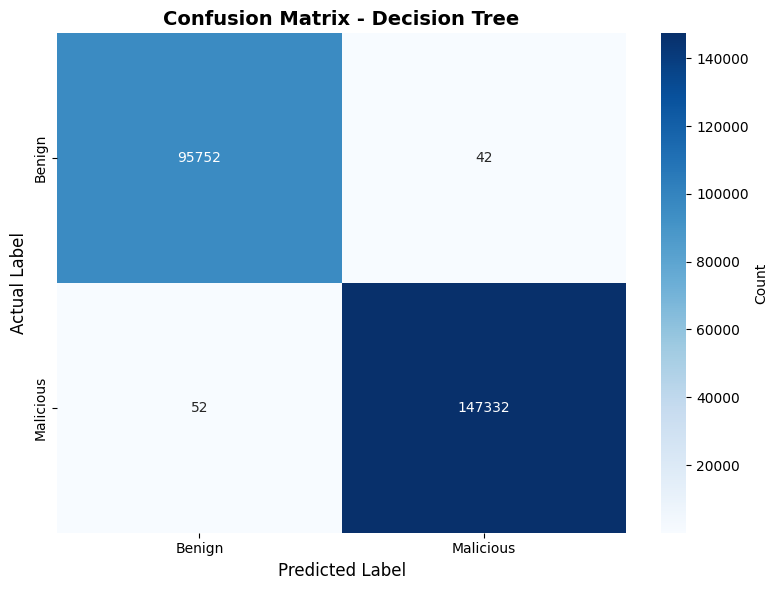

True Negatives: 95,752
False Positives: 42
False Negatives: 52
True Positives: 147,332


In [ ]:
# 1. Confusion Matrix Heatmap
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Malicious'], 
            yticklabels=['Benign', 'Malicious'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Decision Tree', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Tính toán các metrics từ confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives: {tp:,}")

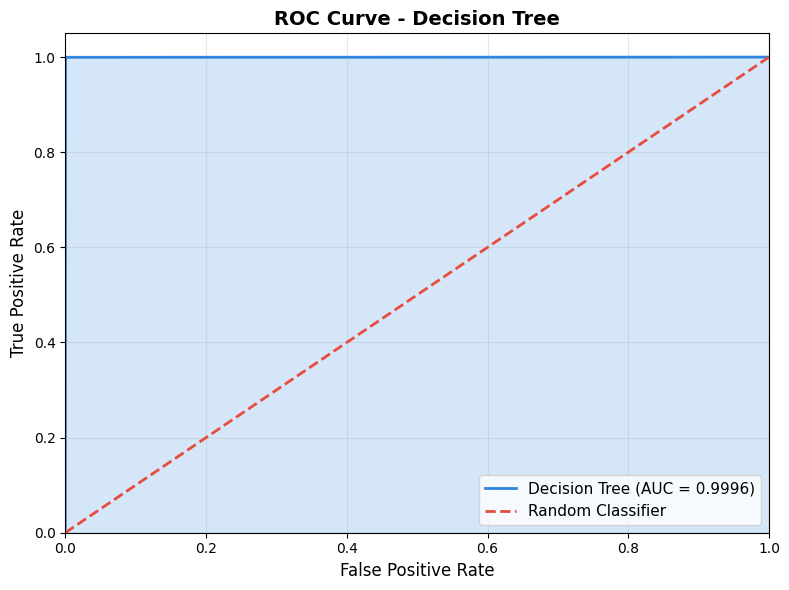

In [ ]:
# 2. ROC Curve
from sklearn.metrics import roc_curve, auc

y_proba = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1], pos_label='Malicious')
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2E86DE', linewidth=2, label=f'Decision Tree (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#E74C3C', linestyle='--', linewidth=2, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.2, color='#2E86DE')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Decision Tree', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

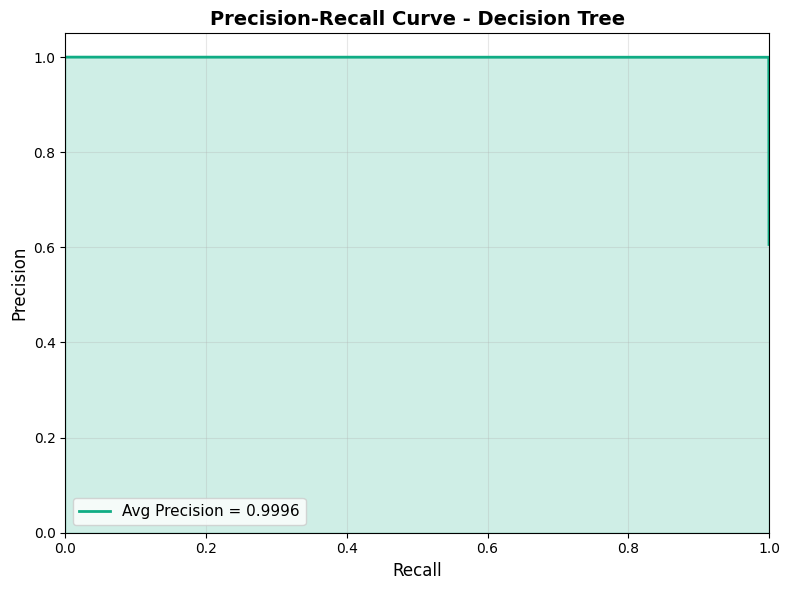

In [ ]:
# 3. Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label='Malicious')
avg_precision = average_precision_score(y_test == 'Malicious', y_proba[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#10AC84', linewidth=2, label=f'Avg Precision = {avg_precision:.4f}')
plt.fill_between(recall, precision, alpha=0.2, color='#10AC84')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - Decision Tree', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

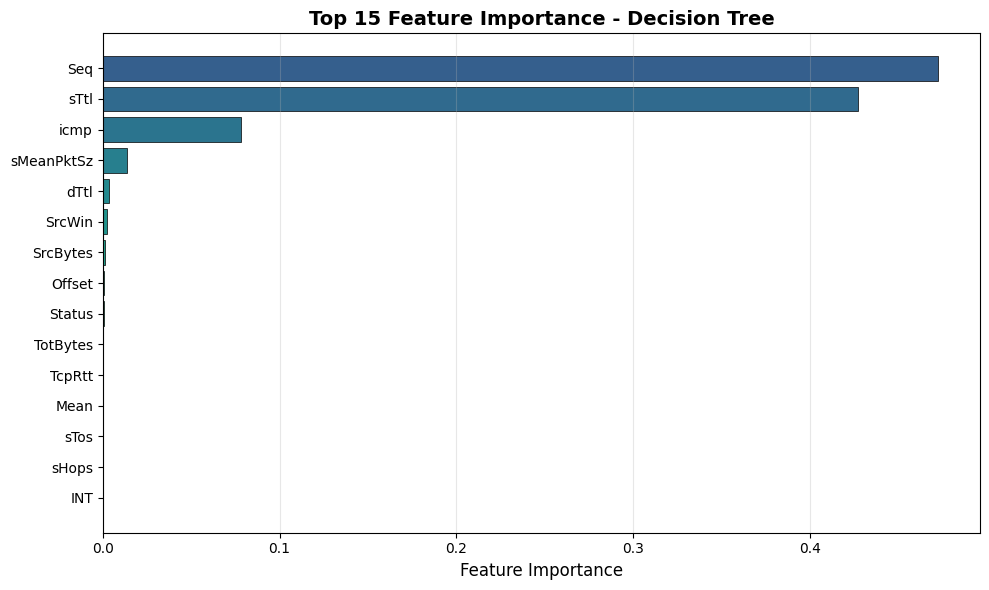

In [ ]:
# 4. Feature Importance
feature_names = df.columns[0:24].tolist()
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # Top 15 features

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(indices)))
plt.barh(range(len(indices)), importances[indices], color=colors, edgecolor='black', linewidth=0.5)
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Feature Importance - Decision Tree', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

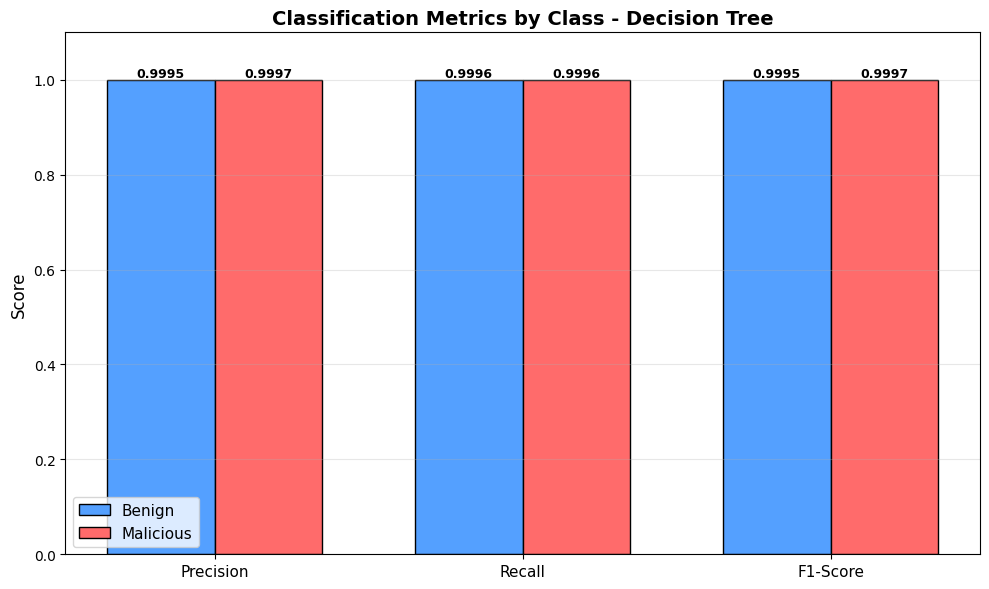

In [ ]:
# 5. Classification Metrics Comparison
from sklearn.metrics import precision_recall_fscore_support

precision_scores, recall_scores, f1_scores, support = precision_recall_fscore_support(
    y_test, y_pred, labels=['Benign', 'Malicious']
)

metrics_data = {
    'Benign': [precision_scores[0], recall_scores[0], f1_scores[0]],
    'Malicious': [precision_scores[1], recall_scores[1], f1_scores[1]]
}

x = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, metrics_data['Benign'], width, 
               label='Benign', color='#54A0FF', edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, metrics_data['Malicious'], width, 
               label='Malicious', color='#FF6B6B', edgecolor='black', linewidth=1)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Classification Metrics by Class - Decision Tree', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Precision', 'Recall', 'F1-Score'], fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

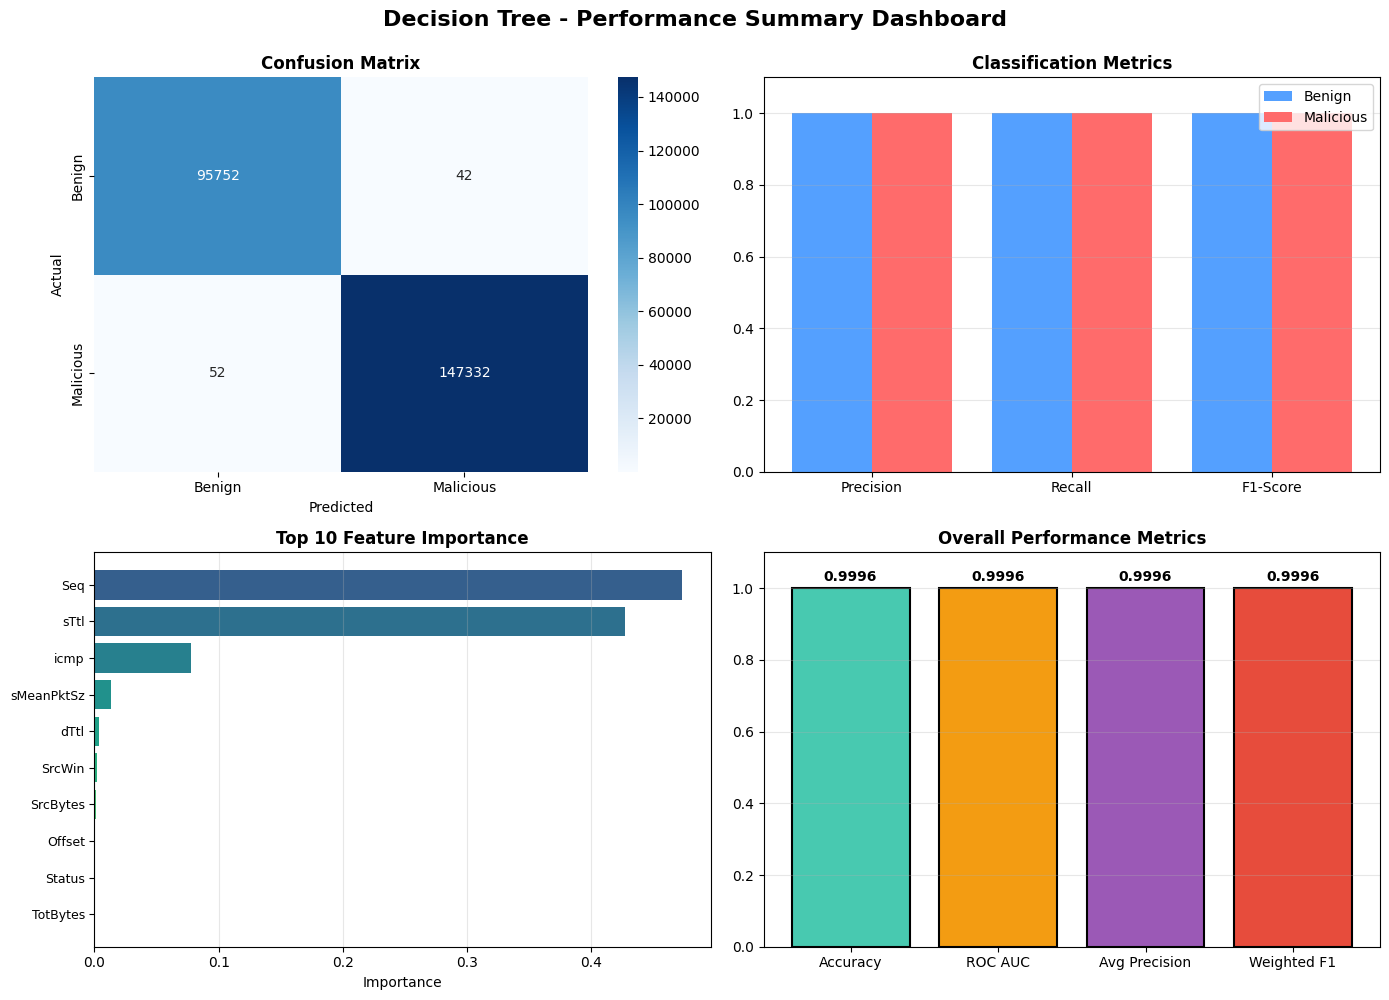

In [ ]:
# 6. Performance Summary Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Decision Tree - Performance Summary Dashboard', fontsize=16, fontweight='bold', y=0.995)

# Subplot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Benign', 'Malicious'], 
            yticklabels=['Benign', 'Malicious'])
axes[0, 0].set_title('Confusion Matrix', fontweight='bold')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# Subplot 2: Metrics Comparison
metrics_labels = ['Precision', 'Recall', 'F1-Score']
benign_vals = [precision_scores[0], recall_scores[0], f1_scores[0]]
malicious_vals = [precision_scores[1], recall_scores[1], f1_scores[1]]
x_pos = np.arange(len(metrics_labels))
axes[0, 1].bar(x_pos - 0.2, benign_vals, 0.4, label='Benign', color='#54A0FF')
axes[0, 1].bar(x_pos + 0.2, malicious_vals, 0.4, label='Malicious', color='#FF6B6B')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(metrics_labels)
axes[0, 1].set_ylim([0, 1.1])
axes[0, 1].set_title('Classification Metrics', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Subplot 3: Top 10 Features
top_10_indices = indices[:10]
axes[1, 0].barh(range(len(top_10_indices)), importances[top_10_indices], 
                color=plt.cm.viridis(np.linspace(0.3, 0.9, 10)))
axes[1, 0].set_yticks(range(len(top_10_indices)))
axes[1, 0].set_yticklabels([feature_names[i] for i in top_10_indices], fontsize=9)
axes[1, 0].set_xlabel('Importance')
axes[1, 0].set_title('Top 10 Feature Importance', fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# Subplot 4: Model Performance Metrics
metrics_summary = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'ROC AUC': roc_auc,
    'Avg Precision': avg_precision,
    'Weighted F1': f1_scores.mean()
}
colors_map = ['#48C9B0', '#F39C12', '#9B59B6', '#E74C3C']
axes[1, 1].bar(metrics_summary.keys(), metrics_summary.values(), 
               color=colors_map, edgecolor='black', linewidth=1.5)
axes[1, 1].set_ylim([0, 1.1])
axes[1, 1].set_title('Overall Performance Metrics', fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(metrics_summary.items()):
    axes[1, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## Lưu Mô hình

In [ ]:
# Lưu mô hình Decision Tree và Scaler
import joblib
from datetime import datetime

# Tạo tên file với timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Lưu mô hình Decision Tree
model_filename = f'decision_tree_model_{timestamp}.pkl'
joblib.dump(model, model_filename)
print(f"✓ Đã lưu mô hình Decision Tree: {model_filename}")

# Lưu scaler
scaler_filename = f'scaler_{timestamp}.pkl'
joblib.dump(scaler, scaler_filename)
print(f"✓ Đã lưu scaler: {scaler_filename}")

# Lưu feature names để sử dụng sau này
feature_names_filename = f'feature_names_{timestamp}.pkl'
joblib.dump(feature_names, feature_names_filename)
print(f"✓ Đã lưu tên các features: {feature_names_filename}")

# Hiển thị thông tin mô hình đã lưu
print("\n" + "="*60)
print("THÔNG TIN MÔ HÌNH ĐÃ LƯU")
print("="*60)
print(f"Mô hình: Decision Tree Classifier")
print(f"Số features: {len(feature_names)}")
print(f"Max depth: {model.tree_.max_depth}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("="*60)

✓ Đã lưu mô hình Decision Tree: decision_tree_model_20260227_205406.pkl
✓ Đã lưu scaler: scaler_20260227_205406.pkl
✓ Đã lưu tên các features: feature_names_20260227_205406.pkl

THÔNG TIN MÔ HÌNH ĐÃ LƯU
Mô hình: Decision Tree Classifier
Số features: 24
Max depth: 220
Accuracy: 0.9996
ROC AUC: 0.9996


In [ ]:
# Code mẫu để load lại mô hình đã lưu
"""
# Load mô hình đã lưu
import joblib

# Load các file (thay tên file tương ứng)
loaded_model = joblib.load('decision_tree_model_YYYYMMDD_HHMMSS.pkl')
loaded_scaler = joblib.load('scaler_YYYYMMDD_HHMMSS.pkl')
loaded_features = joblib.load('feature_names_YYYYMMDD_HHMMSS.pkl')

# Sử dụng mô hình để dự đoán
# X_new = scaler.transform(X_new_data)
# predictions = loaded_model.predict(X_new)
"""
print("Code mẫu để load mô hình đã được chuẩn bị ở trên (uncomment để sử dụng)")

Code mẫu để load mô hình đã được chuẩn bị ở trên (uncomment để sử dụng)


## Mô phỏng Phát hiện Hành vi Bất thường trong Mạng IoT 5G